# POSTTEST 2
## Data Preprocessing

Nama: Intan Alfara Audia  
NIM: 2409106008  
Kelas: Informatika A24

## 1. Pendahuluan

Pada praktikum ini dilakukan data preprocessing menggunakan dataset
Palmer Archipelago (Antarctica) Penguin Data yang telah digunakan pada Posttest 1.

Data preprocessing dilakukan untuk mempersiapkan data sebelum digunakan
pada proses analisis atau pemodelan lebih lanjut.

Tahapan preprocessing yang dilakukan meliputi data cleaning, handling
missing value, handling duplicate value, handling outlier, standardisasi
kolom numerik, encoding kolom kategorikal, dan feature engineering.

In [ ]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import seaborn as sns

## 2. Membaca Dataset

Dataset dibaca menggunakan Pandas. Setelah dataset dibaca, dilakukan
pengecekan ukuran data untuk mengetahui jumlah record dan attribute
yang digunakan dalam preprocessing.

In [ ]:
df = pd.read_csv("penguins_lter.csv")

print("Jumlah record :", df.shape[0])
print("Jumlah attribute :", df.shape[1])

df.head()

Jumlah record : 344
Jumlah attribute : 17


,studyName,Sample Number,Species,Region,Island,Stage,Individual ID,Clutch Completion,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex,Delta 15 N (o/oo),Delta 13 C (o/oo),Comments
0,PAL0708,1,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N1A1,Yes,11/11/07,39.1,18.7,181.0,3750.0,MALE,NaN,NaN,Not enough blood for isotopes.
1,PAL0708,2,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N1A2,Yes,11/11/07,39.5,17.4,186.0,3800.0,FEMALE,8.94956,-24.69454,NaN
2,PAL0708,3,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N2A1,Yes,11/16/07,40.3,18.0,195.0,3250.0,FEMALE,8.36821,-25.33302,NaN
3,PAL0708,4,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N2A2,Yes,11/16/07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Adult not sampled.
4,PAL0708,5,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N3A1,Yes,11/16/07,36.7,19.3,193.0,3450.0,FEMALE,8.76651,-25.32426,NaN


# 1. DATA CLEANING

## 3. Pengecekan Missing Value

Missing value merupakan data yang tidak memiliki nilai pada suatu
attribute.

Pengecekan dilakukan terlebih dahulu agar dapat diketahui attribute mana
yang memiliki data kosong sebelum menentukan cara penanganannya.

In [ ]:
missing_value = pd.DataFrame({
    "Jumlah Missing": df.isnull().sum(),
    "Persentase Missing (%)": df.isnull().mean() * 100
})

missing_value

,Jumlah Missing,Persentase Missing (%)
studyName,0,0.000000
Sample Number,0,0.000000
Species,0,0.000000
Region,0,0.000000
Island,0,0.000000
Stage,0,0.000000
Individual ID,0,0.000000
Clutch Completion,0,0.000000
Date Egg,0,0.000000
Culmen Length (mm),2,0.581395


## 4. Handling Missing Value

Missing value pada attribute numerik diisi menggunakan median. Median
dipilih karena lebih tahan terhadap nilai yang terlalu besar atau terlalu
kecil dibandingkan mean.

Missing value pada attribute kategorikal diisi menggunakan modus, yaitu
kategori yang paling sering muncul. Dengan cara ini record tidak perlu
langsung dihapus sehingga jumlah data tetap dipertahankan.

In [ ]:
numeric_columns = df.select_dtypes(include=np.number).columns
object_columns = df.select_dtypes(include="object").columns

for column in numeric_columns:
    df[column] = df[column].fillna(df[column].median())

for column in object_columns:
    if df[column].isnull().sum() > 0:
        df[column] = df[column].fillna(df[column].mode()[0])

print("Total missing value setelah handling:",
      df.isnull().sum().sum())

Total missing value setelah handling: 0


## 5. Pengecekan Setelah Handling Missing Value

Pengecekan ulang dilakukan untuk memastikan missing value sudah
ditangani pada seluruh attribute.

In [ ]:
missing_after = df.isnull().sum()

display(missing_after.to_frame("Jumlah Missing"))
print("Total missing value :", missing_after.sum())

,Jumlah Missing
studyName,0
Sample Number,0
Species,0
Region,0
Island,0
Stage,0
Individual ID,0
Clutch Completion,0
Date Egg,0
Culmen Length (mm),0


Total missing value : 0


## 6. Pengecekan Duplicate Value

Duplicate value adalah record yang memiliki isi sama dengan record
lainnya. Pengecekan dilakukan untuk mengetahui apakah terdapat data yang
tercatat lebih dari satu kali.

In [ ]:
jumlah_duplicate = df.duplicated().sum()

print("Jumlah data duplikat :", jumlah_duplicate)

Jumlah data duplikat : 0


## 7. Handling Duplicate Value

Jika terdapat duplicate value, record tersebut dihapus karena data yang
sama tidak memberikan informasi tambahan dan dapat memengaruhi analisis.

Jika tidak terdapat duplicate, tidak ada record yang dihapus.

In [ ]:
df = df.drop_duplicates().reset_index(drop=True)

print("Jumlah record setelah handling duplicate :", df.shape[0])

Jumlah record setelah handling duplicate : 344


# 2. HANDLING OUTLIER

## 8. Pengecekan Outlier

Outlier adalah nilai yang memiliki jarak cukup jauh dari sebagian besar
data lainnya.

Pengecekan outlier dilakukan pada attribute numerik yang berupa hasil
pengukuran. `Sample Number` tidak digunakan karena merupakan nomor
sampel, bukan hasil pengukuran karakteristik penguin.

Metode yang digunakan adalah IQR (Interquartile Range). Nilai di luar
batas bawah dan batas atas IQR dianggap sebagai outlier.

In [ ]:
measurement_columns = [
    "Culmen Length (mm)",
    "Culmen Depth (mm)",
    "Flipper Length (mm)",
    "Body Mass (g)",
    "Delta 15 N (o/oo)",
    "Delta 13 C (o/oo)"
]

outlier_summary = []

for column in measurement_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    batas_bawah = Q1 - 1.5 * IQR
    batas_atas = Q3 + 1.5 * IQR

    jumlah_outlier = (
        (df[column] < batas_bawah) |
        (df[column] > batas_atas)
    ).sum()

    outlier_summary.append({
        "Attribute": column,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Batas Bawah": batas_bawah,
        "Batas Atas": batas_atas,
        "Jumlah Outlier": jumlah_outlier
    })

outlier_summary = pd.DataFrame(outlier_summary)
outlier_summary

,Attribute,Q1,Q3,IQR,Batas Bawah,Batas Atas,Jumlah Outlier
0,Culmen Length (mm),39.275000,48.500000,9.225000,25.437500,62.337500,0
1,Culmen Depth (mm),15.600000,18.700000,3.100000,10.950000,23.350000,0
2,Flipper Length (mm),190.000000,213.000000,23.000000,155.500000,247.500000,0
3,Body Mass (g),3550.000000,4750.000000,1200.000000,1750.000000,6550.000000,0
4,Delta 15 N (o/oo),8.307415,9.136170,0.828755,7.064283,10.379302,0
5,Delta 13 C (o/oo),-26.285460,-25.089467,1.195993,-28.079449,-23.295479,0


## 9. Visualisasi Outlier

Selain perhitungan IQR, outlier dilihat menggunakan boxplot. Boxplot
dapat memperlihatkan persebaran data dan nilai yang berada jauh dari
bagian utama data.

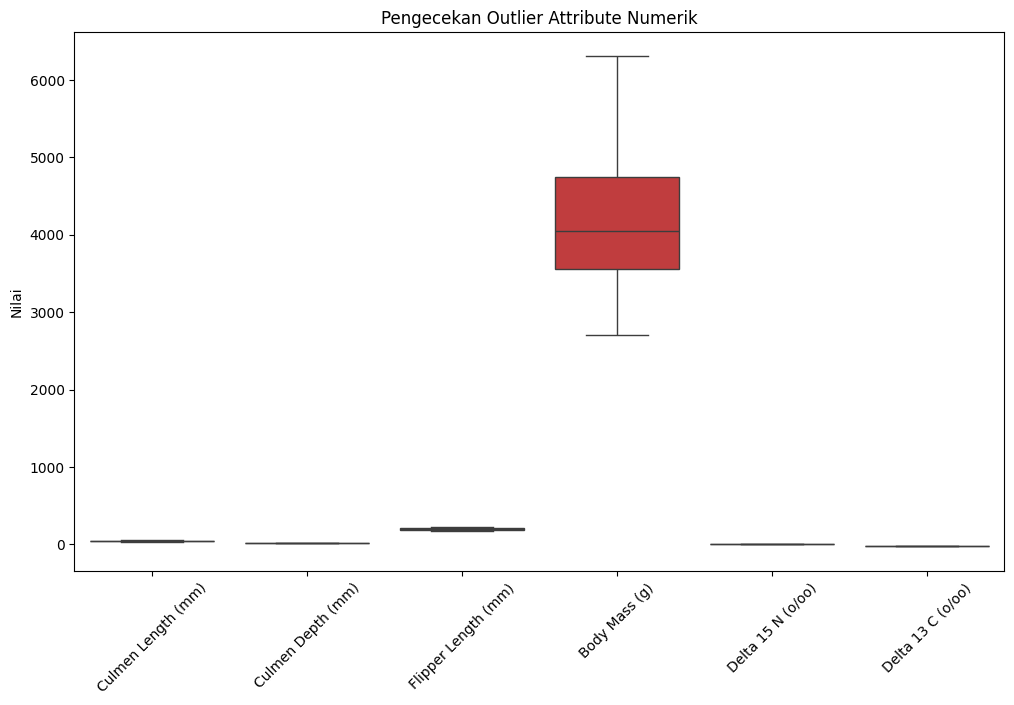

In [ ]:
plt.figure(figsize=(12, 7))

sns.boxplot(data=df[measurement_columns])

plt.title("Pengecekan Outlier Attribute Numerik")
plt.xticks(rotation=45)
plt.ylabel("Nilai")

plt.show()

## 10. Handling Outlier dengan IQR Capping

Outlier tidak langsung dihapus karena setiap record masih dapat memiliki
informasi yang berguna.

Digunakan metode IQR capping. Nilai di bawah batas bawah diganti dengan
batas bawah, sedangkan nilai di atas batas atas diganti dengan batas atas.
Dengan demikian record tetap dipertahankan, tetapi pengaruh nilai ekstrem
dibatasi.

In [ ]:
for column in measurement_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    batas_bawah = Q1 - 1.5 * IQR
    batas_atas = Q3 + 1.5 * IQR

    df[column] = df[column].clip(
        lower=batas_bawah,
        upper=batas_atas
    )

print("Handling outlier selesai.")

Handling outlier selesai.


# 3. FEATURE ENGINEERING

## 11. Feature Engineering

Feature engineering dilakukan dengan membuat attribute baru dari
attribute yang sudah tersedia.

Feature baru yang dibuat adalah `Body Mass per Flipper`, yaitu hasil
pembagian Body Mass dengan Flipper Length.

Feature ini digunakan untuk melihat perbandingan massa tubuh terhadap
panjang sirip pada setiap penguin.

Feature ini tidak menggunakan `Species` sehingga tidak menyentuh target
label.

In [ ]:
df["Body Mass per Flipper"] = (
    df["Body Mass (g)"] / df["Flipper Length (mm)"]
)

df[[
    "Body Mass (g)",
    "Flipper Length (mm)",
    "Body Mass per Flipper"
]].head(10)

,Body Mass (g),Flipper Length (mm),Body Mass per Flipper
0,3750.0,181.0,20.718232
1,3800.0,186.0,20.430108
2,3250.0,195.0,16.666667
3,4050.0,197.0,20.558376
4,3450.0,193.0,17.875648
5,3650.0,190.0,19.210526
6,3625.0,181.0,20.027624
7,4675.0,195.0,23.974359
8,3475.0,193.0,18.005181
9,4250.0,190.0,22.368421


# 4. STANDARDISASI KOLOM NUMERIK

## 12. Standardisasi Kolom Numerik

Standardisasi dilakukan agar attribute numerik memiliki skala yang lebih
seragam.

Metode yang digunakan adalah StandardScaler. `Sample Number` tidak
distandarisasi karena merupakan nomor sampel, bukan ukuran karakteristik
penguin.

In [ ]:
standard_columns = measurement_columns + ["Body Mass per Flipper"]

scaler = StandardScaler()

df[standard_columns] = scaler.fit_transform(
    df[standard_columns]
)

df[standard_columns].head(10)

,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Delta 15 N (o/oo),Delta 13 C (o/oo),Body Mass per Flipper
0,-0.887622,0.787289,-1.420541,-0.564625,-0.143896,-0.182055,-0.020916
1,-0.814037,0.126114,-1.063485,-0.502010,0.406551,1.281659,-0.125717
2,-0.666866,0.431272,-0.420786,-1.190773,-0.670335,0.461143,-1.494622
3,0.096581,0.075255,-0.277964,-0.188936,-0.143896,-0.182055,-0.079061
4,-1.329133,1.092447,-0.563608,-0.940314,0.067471,0.472400,-1.054870
5,-0.850829,1.753622,-0.777841,-0.689855,-0.120639,0.506083,-0.569325
6,-0.924414,0.329553,-1.420541,-0.721162,0.846715,0.608969,-0.272116
7,-0.869226,1.245026,-0.420786,0.593748,1.353196,1.018161,1.163460
8,-1.807437,0.482132,-0.563608,-0.909007,-0.143896,-0.182055,-1.007754
9,-0.354129,1.550184,-0.777841,0.061523,0.747502,0.768721,0.579320


## 13. Melihat Hasil Standardisasi

Setelah standardisasi dilakukan, statistik deskriptif ditampilkan kembali
untuk melihat hasil perubahan skala pada attribute yang telah distandarisasi.

In [ ]:
df[standard_columns].describe()

,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Delta 15 N (o/oo),Delta 13 C (o/oo),Body Mass per Flipper
count,3.440000e+02,3.440000e+02,3.440000e+02,3.440000e+02,3.440000e+02,3.440000e+02,3.440000e+02
mean,-7.435912e-16,2.891744e-16,2.891744e-16,8.262125e-17,1.487182e-15,-6.800762e-15,3.304850e-16
std,1.001457e+00,1.001457e+00,1.001457e+00,1.001457e+00,1.001457e+00,1.001457e+00,1.001457e+00
min,-2.175363e+00,-2.060850e+00,-2.063241e+00,-1.879536e+00,-2.033712e+00,-1.704935e+00,-2.441854e+00
25%,-8.554283e-01,-7.893593e-01,-7.778411e-01,-8.150844e-01,-7.829512e-01,-7.628469e-01,-7.145412e-01
50%,9.658061e-02,7.525452e-02,-2.779635e-01,-1.889365e-01,-1.438956e-01,-1.820545e-01,-9.072275e-02
75%,8.416311e-01,7.872894e-01,8.646139e-01,6.876706e-01,7.522251e-01,7.741344e-01,6.905682e-01
max,2.883621e+00,2.211359e+00,2.150013e+00,2.628729e+00,2.399499e+00,2.447087e+00,2.812073e+00


# 5. ENCODING KOLOM KATEGORIKAL

## 14. Menentukan Attribute Kategorikal yang Akan Di-Encode

Attribute bertipe object tidak semuanya harus langsung diubah menjadi
angka.

`Species` dipertahankan sebagai target label sehingga tidak ikut di-encode.
`Individual ID` merupakan identitas individu, sehingga tidak digunakan
sebagai fitur kategorikal.

`Comments` merupakan catatan teks bebas, sehingga tidak sesuai untuk
One-Hot Encoding biasa.

`Date Egg` memiliki informasi waktu sehingga akan diolah sebagai tanggal.

Attribute kategorikal yang digunakan sebagai fitur adalah:
`studyName`, `Region`, `Island`, `Stage`, `Clutch Completion`, dan `Sex`.

Attribute tersebut tidak memiliki urutan alami, sehingga digunakan
One-Hot Encoding.

In [ ]:
categorical_columns = [
    "studyName",
    "Region",
    "Island",
    "Stage",
    "Clutch Completion",
    "Sex"
]

print("Attribute yang akan di-One-Hot Encoding:")
for column in categorical_columns:
    print("-", column)

Attribute yang akan di-One-Hot Encoding:
- studyName
- Region
- Island
- Stage
- Clutch Completion
- Sex


## 15. One-Hot Encoding

One-Hot Encoding digunakan karena kategori pada attribute yang dipilih
tidak memiliki urutan alami.

Setiap kategori akan dibuat menjadi kolom baru dengan nilai 0 atau 1.

In [ ]:
df_encoded = pd.get_dummies(
    df,
    columns=categorical_columns,
    dtype=int
)

df_encoded.head()

,Sample Number,Species,Individual ID,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Delta 15 N (o/oo),Delta 13 C (o/oo),...,Region_Anvers,Island_Biscoe,Island_Dream,Island_Torgersen,"Stage_Adult, 1 Egg Stage",Clutch Completion_No,Clutch Completion_Yes,Sex_.,Sex_FEMALE,Sex_MALE
0,1,Adelie Penguin (Pygoscelis adeliae),N1A1,11/11/07,-0.887622,0.787289,-1.420541,-0.564625,-0.143896,-0.182055,...,1,0,0,1,1,0,1,0,0,1
1,2,Adelie Penguin (Pygoscelis adeliae),N1A2,11/11/07,-0.814037,0.126114,-1.063485,-0.502010,0.406551,1.281659,...,1,0,0,1,1,0,1,0,1,0
2,3,Adelie Penguin (Pygoscelis adeliae),N2A1,11/16/07,-0.666866,0.431272,-0.420786,-1.190773,-0.670335,0.461143,...,1,0,0,1,1,0,1,0,1,0
3,4,Adelie Penguin (Pygoscelis adeliae),N2A2,11/16/07,0.096581,0.075255,-0.277964,-0.188936,-0.143896,-0.182055,...,1,0,0,1,1,0,1,0,0,1
4,5,Adelie Penguin (Pygoscelis adeliae),N3A1,11/16/07,-1.329133,1.092447,-0.563608,-0.940314,0.067471,0.472400,...,1,0,0,1,1,0,1,0,1,0


## 16. Mengolah Attribute Date Egg

`Date Egg` merupakan data tanggal, sehingga tidak dilakukan One-Hot
Encoding terhadap setiap tanggal.

Attribute tersebut diubah menjadi tipe datetime, kemudian dibuat feature
baru berupa bulan telur dicatat. Cara ini mempertahankan informasi waktu
tanpa menghasilkan terlalu banyak kolom.

In [ ]:
df_encoded["Date Egg"] = pd.to_datetime(
    df_encoded["Date Egg"],
    errors="coerce"
)

df_encoded["Egg Month"] = df_encoded["Date Egg"].dt.month

df_encoded[[
    "Date Egg",
    "Egg Month"
]].head(10)

/tmp/ipykernel_4634/3016093090.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_encoded["Date Egg"] = pd.to_datetime(


,Date Egg,Egg Month
0,2007-11-11,11
1,2007-11-11,11
2,2007-11-16,11
3,2007-11-16,11
4,2007-11-16,11
5,2007-11-16,11
6,2007-11-15,11
7,2007-11-15,11
8,2007-11-09,11
9,2007-11-09,11


# 6. CEK HASIL AKHIR PREPROCESSING

## 17. Melihat Hasil Akhir Preprocessing

Setelah seluruh tahapan preprocessing dilakukan, dilakukan pengecekan
jumlah record, jumlah attribute, dan beberapa record pertama.

In [ ]:
print("Jumlah record :", df_encoded.shape[0])
print("Jumlah attribute :", df_encoded.shape[1])

df_encoded.head()

Jumlah record : 344
Jumlah attribute : 26


,Sample Number,Species,Individual ID,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Delta 15 N (o/oo),Delta 13 C (o/oo),...,Island_Biscoe,Island_Dream,Island_Torgersen,"Stage_Adult, 1 Egg Stage",Clutch Completion_No,Clutch Completion_Yes,Sex_.,Sex_FEMALE,Sex_MALE,Egg Month
0,1,Adelie Penguin (Pygoscelis adeliae),N1A1,2007-11-11,-0.887622,0.787289,-1.420541,-0.564625,-0.143896,-0.182055,...,0,0,1,1,0,1,0,0,1,11
1,2,Adelie Penguin (Pygoscelis adeliae),N1A2,2007-11-11,-0.814037,0.126114,-1.063485,-0.502010,0.406551,1.281659,...,0,0,1,1,0,1,0,1,0,11
2,3,Adelie Penguin (Pygoscelis adeliae),N2A1,2007-11-16,-0.666866,0.431272,-0.420786,-1.190773,-0.670335,0.461143,...,0,0,1,1,0,1,0,1,0,11
3,4,Adelie Penguin (Pygoscelis adeliae),N2A2,2007-11-16,0.096581,0.075255,-0.277964,-0.188936,-0.143896,-0.182055,...,0,0,1,1,0,1,0,0,1,11
4,5,Adelie Penguin (Pygoscelis adeliae),N3A1,2007-11-16,-1.329133,1.092447,-0.563608,-0.940314,0.067471,0.472400,...,0,0,1,1,0,1,0,1,0,11


## 18. Pengecekan Missing Value Setelah Preprocessing

Pengecekan dilakukan untuk memastikan tidak terdapat missing value
setelah seluruh tahapan data cleaning dan feature engineering.

In [ ]:
print(
    "Total missing value setelah preprocessing :",
    df_encoded.isnull().sum().sum()
)

Total missing value setelah preprocessing : 0


## 19. Pengecekan Duplicate Setelah Preprocessing

Pengecekan duplicate dilakukan kembali untuk memastikan tidak terdapat
record yang sama setelah preprocessing.

In [ ]:
print(
    "Jumlah duplicate setelah preprocessing :",
    df_encoded.duplicated().sum()
)

Jumlah duplicate setelah preprocessing : 0


## 20. Melihat Attribute Setelah Preprocessing

Seluruh nama attribute ditampilkan untuk melihat perubahan struktur
dataset setelah encoding dan feature engineering.

In [ ]:
print("Daftar attribute setelah preprocessing:")

for i, column in enumerate(df_encoded.columns, 1):
    print(f"{i}. {column}")

Daftar attribute setelah preprocessing:
1. Sample Number
2. Species
3. Individual ID
4. Date Egg
5. Culmen Length (mm)
6. Culmen Depth (mm)
7. Flipper Length (mm)
8. Body Mass (g)
9. Delta 15 N (o/oo)
10. Delta 13 C (o/oo)
11. Comments
12. Body Mass per Flipper
13. studyName_PAL0708
14. studyName_PAL0809
15. studyName_PAL0910
16. Region_Anvers
17. Island_Biscoe
18. Island_Dream
19. Island_Torgersen
20. Stage_Adult, 1 Egg Stage
21. Clutch Completion_No
22. Clutch Completion_Yes
23. Sex_.
24. Sex_FEMALE
25. Sex_MALE
26. Egg Month


## 21. Menyimpan Dataset Hasil Preprocessing

Dataset hasil preprocessing disimpan dalam format CSV agar dapat
digunakan kembali untuk proses analisis atau pemodelan selanjutnya.

In [ ]:
df_encoded.to_csv(
    "penguins_preprocessed.csv",
    index=False
)

print("Dataset hasil preprocessing berhasil disimpan.")

Dataset hasil preprocessing berhasil disimpan.


# 7. KESIMPULAN

Pada praktikum ini telah dilakukan preprocessing pada dataset Palmer
Archipelago (Antarctica) Penguin Data.

Tahapan yang dilakukan meliputi handling missing value, handling
duplicate value, handling outlier, standardisasi kolom numerik,
encoding kolom kategorikal, dan feature engineering.

Missing value numerik ditangani menggunakan median, sedangkan missing
value kategorikal ditangani menggunakan modus. Duplicate value dihapus
jika ditemukan.

Outlier pada attribute hasil pengukuran diperiksa menggunakan metode IQR
dan ditangani menggunakan IQR capping agar record tetap dipertahankan.

Standardisasi dilakukan menggunakan StandardScaler pada attribute
pengukuran dan feature baru. Encoding dilakukan menggunakan One-Hot
Encoding pada attribute kategorikal yang tidak memiliki urutan alami.

`Species` tidak di-encode karena dipertahankan sebagai target label.
`Individual ID` tidak digunakan sebagai fitur kategorikal karena
merupakan identitas individu, sedangkan `Comments` merupakan catatan
teks bebas. `Date Egg` diolah sebagai data tanggal dan menghasilkan
feature `Egg Month`.

Feature engineering dilakukan dengan membuat `Body Mass per Flipper`,
yaitu perbandingan Body Mass dengan Flipper Length. Feature tersebut
tidak menggunakan target label.

Dengan demikian, dataset telah melalui tahapan preprocessing dan
disiapkan untuk digunakan pada proses analisis atau pemodelan
selanjutnya.